# Adjacency Tier Discovery — BB 기반 연결의 3단계 품질 분류

**Finding M2**: DXTnavis adjacency 220K 간선은 바운딩 박스(AABB) 기반이며, 물리적 접촉이 아닙니다.
간선을 연결 강도별 3단계로 분류하면 precedence DAG 의 critical chain 이 88 → 17 steps 로 변합니다.

이 노트북은:
1. adjacency 판정 기준 분석 (AABB 근거)
2. 3단계 분류: Strong / Medium / Weak
3. A/B 테스트: 분류별 precedence DAG 영향
4. 사례 연구: Pipeline U01-UA-2001 의 시공 순서
5. Neo4j 환경 및 Cypher 질의 참조

관련: [Finding M2](../docs/findings/2026-04-12-M2-adjacency-tiers/README.md)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from bimkg import config
from bimkg.analytics.metrics import build_physical_graph
from bimkg.analytics.zones import assign_louvain_zones
from bimkg.analytics.precedence import build_precedence_dag, find_longest_chain, critical_chain_summary

sns.set_theme(style="whitegrid", font_scale=1.1)

gold = pd.read_parquet(config.ENRICHED_OBJECTS)
adj = pd.read_parquet(config.ENRICHED_ADJACENCY_SYM)

print(f"Gold: {len(gold):,} objects × {gold.shape[1]} cols")
print(f"Adjacency: {len(adj):,} edges (symmetric)")
print(f"Columns: {list(adj.columns)}")

from pathlib import Path
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

Gold: 12,009 objects × 219 cols
Adjacency: 220,346 edges (symmetric)
Columns: ['source_object_id', 'target_object_id', 'source_name', 'target_name', 'distance_m', 'overlap_volume_m3', 'relation_type', 'source_category', 'target_category', 'tolerance_m']


## 1. Adjacency 판정 기준 — AABB 근거

DXTnavis 는 Navisworks API 의 바운딩 박스(AABB) 기반 근접 판정을 사용합니다.
**물리적 표면 접촉이 아닙니다.**

근거:
- 최대 overlap 41,150 m³ = 한 변 34.5m 정육면체 — 실제 물체가 이만큼 겹칠 수 없음
- 큰 overlap 의 정체는 시스템 레벨 그룹 객체 (B01-PipingSys 등) 의 BB 겹침
- tolerance 0.15m (93%) 로 AABB 근접 탐색

/tmp/ipykernel_3590839/2768367719.py:31: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3590839/2768367719.py:31: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3590839/2768367719.py:31: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3590839/2768367719.py:31: UserWarning: Glyph 52489 (\N{HANGUL SYLLABLE COG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3590839/2768367719.py:31: UserWarning: Glyph 50812 (\N{HANGUL SYLLABLE OEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3590839/2768367719.py:31: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3590839/2768367719.py:31: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaV

/home/taegwan-dev/dev/first-ontology-project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taegwan-dev/dev/first-ontology-project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taegwan-dev/dev/first-ontology-project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taegwan-dev/dev/first-ontology-project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52489 (\N{HANGUL SYLLABLE COG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taegwan-dev/dev/first-ontology-project

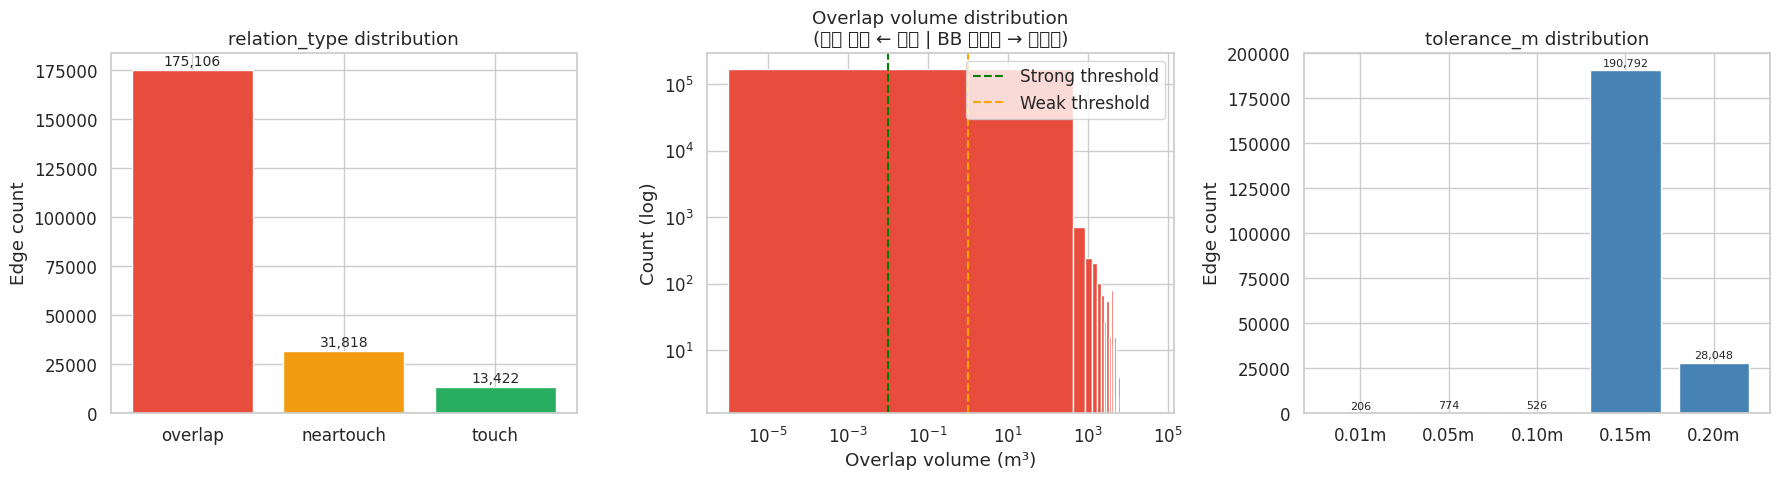

overlap max: 41,150 m³ = cube of 34.5m edge (BB, not physical)
tolerance 0.15m: 190,792 / 220,346 (87%)


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1a. relation_type counts
rt_counts = adj["relation_type"].value_counts()
colors_rt = {"overlap": "#e74c3c", "neartouch": "#f39c12", "touch": "#27ae60"}
axes[0].bar(rt_counts.index, rt_counts.values, color=[colors_rt[r] for r in rt_counts.index])
for i, v in enumerate(rt_counts.values):
    axes[0].text(i, v + 2000, f"{v:,}", ha="center", fontsize=10)
axes[0].set_title("relation_type distribution")
axes[0].set_ylabel("Edge count")

# 1b. overlap_volume distribution (log scale)
ov = adj[adj["relation_type"] == "overlap"]["overlap_volume_m3"]
axes[1].hist(ov[ov > 0], bins=100, log=True, color="#e74c3c", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_xlabel("Overlap volume (m³)")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("Overlap volume distribution\n(실제 접촉 ← 왼쪽 | BB 노이즈 → 오른쪽)")
axes[1].axvline(0.01, color="green", ls="--", label="Strong threshold")
axes[1].axvline(1.0, color="orange", ls="--", label="Weak threshold")
axes[1].legend()

# 1c. tolerance distribution
tol_counts = adj["tolerance_m"].value_counts().sort_index()
axes[2].bar([f"{t:.2f}m" for t in tol_counts.index], tol_counts.values, color="steelblue")
axes[2].set_title("tolerance_m distribution")
axes[2].set_ylabel("Edge count")
for i, v in enumerate(tol_counts.values):
    axes[2].text(i, v + 2000, f"{v:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "03_s1_relation_types.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary stats
print(f"overlap max: {ov.max():,.0f} m³ = cube of {ov.max()**(1/3):.1f}m edge (BB, not physical)")
print(f"tolerance 0.15m: {(adj['tolerance_m'] == 0.15).sum():,} / {len(adj):,} ({(adj['tolerance_m'] == 0.15).mean()*100:.0f}%)")

## 2. 3단계 분류: Strong / Medium / Weak

| 등급 | 조건 | 간선 수 | CM 해석 |
|------|------|--------:|---------|
| **Strong** | `touch` (거리≈0, 겹침=0) | 13,422 | 볼트/용접/플랜지 — 필수 순차 시공 |
| **Medium** | `overlap` < 0.01 m³ | 73,222 | 배관 관통부, 구조물 접합 — 간섭 조율 |
| **Weak** | `overlap` > 1 m³ 또는 `neartouch` | 47,786 | 같은 공간, 직접 접촉 아님 — 순서 무관 |

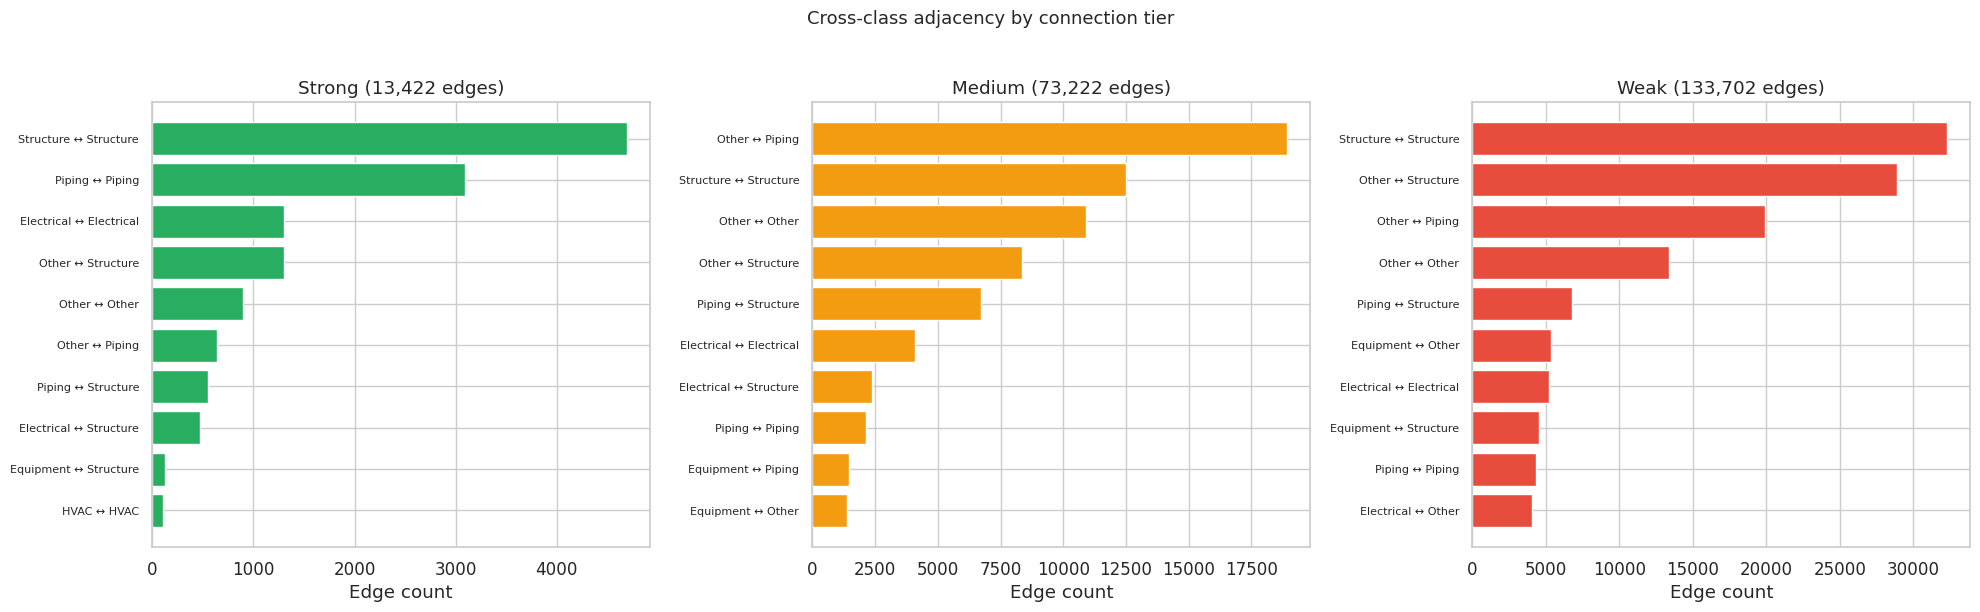

Tier summary:
tier
Weak      133702
Medium     73222
Strong     13422


In [3]:
# Classify edges
def classify_adjacency(row):
    if row["relation_type"] == "touch":
        return "Strong"
    if row["relation_type"] == "overlap" and row["overlap_volume_m3"] < 0.01:
        return "Medium"
    return "Weak"

adj["tier"] = adj.apply(classify_adjacency, axis=1)

# Cross-class adjacency by tier
class_map = dict(zip(gold["object_id"], gold["refined_class"]))
adj["src_class"] = adj["source_object_id"].map(class_map)
adj["tgt_class"] = adj["target_object_id"].map(class_map)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
tier_colors = {"Strong": "#27ae60", "Medium": "#f39c12", "Weak": "#e74c3c"}

for ax, tier in zip(axes, ["Strong", "Medium", "Weak"]):
    sub = adj[adj["tier"] == tier]
    pairs = sub.apply(lambda r: tuple(sorted([r["src_class"] or "?", r["tgt_class"] or "?"])), axis=1)
    top = pairs.value_counts().head(10)
    labels = [f"{a} ↔ {b}" for a, b in top.index]
    ax.barh(range(len(top)), top.values, color=tier_colors[tier])
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Edge count")
    ax.set_title(f"{tier} ({len(sub):,} edges)")
    ax.invert_yaxis()

plt.suptitle("Cross-class adjacency by connection tier", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "03_s2_tier_cross_class.png", dpi=300, bbox_inches="tight")
plt.show()

print("Tier summary:")
print(adj["tier"].value_counts().to_string())

## 3. A/B 테스트: Tier 별 Precedence DAG 영향

동일한 precedence 로직을 adjacency tier 별로 실행하여 critical chain 길이를 비교합니다.

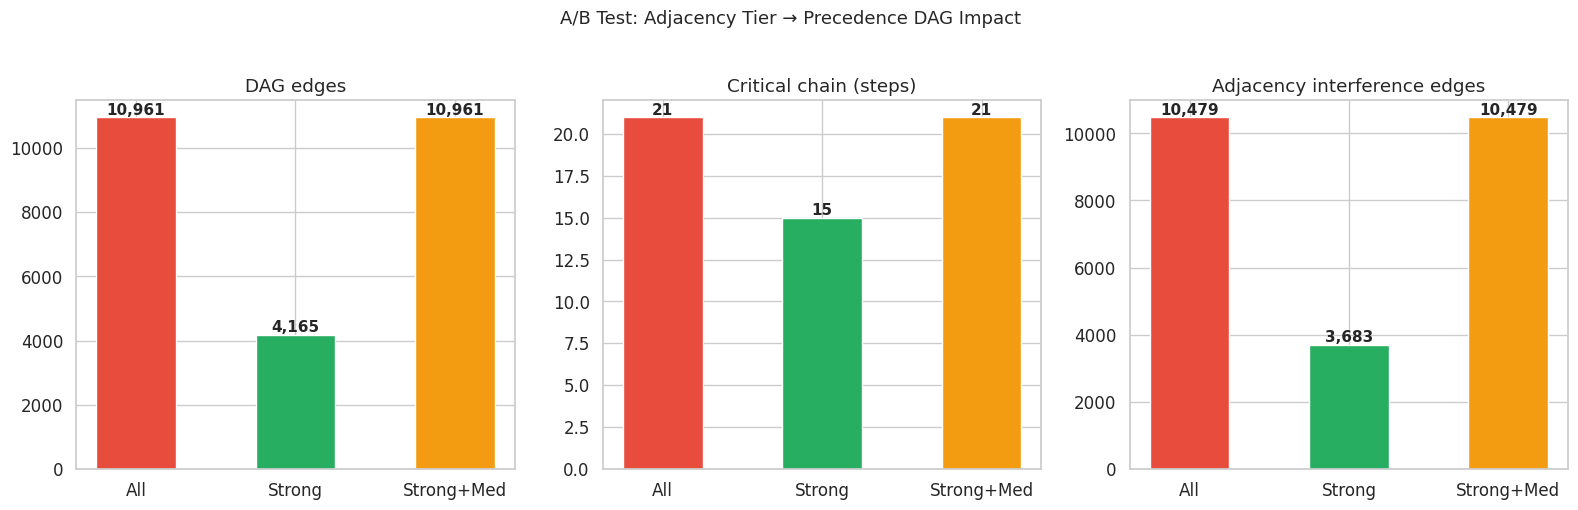

                        dag_edges  critical_chain  class_order_edges  vertical_edges  interference_edges
method                                                                                                  
A: All (220K)               10961              21                150             332               10479
B: Strong only (13K)         4165              15                150             332                3683
C: Strong+Medium (87K)      10961              21                150             332               10479


In [4]:
# Prepare zones
G_full = build_physical_graph(gold, adj)
zone_map = assign_louvain_zones(G_full, resolution=3.0)
gold["zone_id"] = gold["object_id"].map(zone_map)

# Build tier subsets
adj_strong = adj[adj["tier"] == "Strong"]
adj_strong_med = adj[adj["tier"].isin(["Strong", "Medium"])]

results = []
for label, adj_subset in [
    ("A: All (220K)", adj),
    ("B: Strong only (13K)", adj_strong),
    ("C: Strong+Medium (87K)", adj_strong_med),
]:
    dag = build_precedence_dag(gold, adj_subset, zone_col="zone_id")
    chain = find_longest_chain(dag)
    edge_types = {}
    for _, _, d in dag.edges(data=True):
        t = d.get("edge_type", "?")
        edge_types[t] = edge_types.get(t, 0) + 1
    results.append({
        "method": label,
        "dag_edges": dag.number_of_edges(),
        "critical_chain": len(chain),
        "class_order_edges": edge_types.get("class_order", 0),
        "vertical_edges": edge_types.get("vertical", 0),
        "interference_edges": edge_types.get("adjacency_interference", 0),
    })

results_df = pd.DataFrame(results).set_index("method")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors = ["#e74c3c", "#27ae60", "#f39c12"]

for ax, col, title in [
    (axes[0], "dag_edges", "DAG edges"),
    (axes[1], "critical_chain", "Critical chain (steps)"),
    (axes[2], "interference_edges", "Adjacency interference edges"),
]:
    vals = results_df[col]
    bars = ax.bar(["All", "Strong", "Strong+Med"], vals, color=bar_colors, width=0.5)
    ax.set_title(title)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.suptitle("A/B Test: Adjacency Tier → Precedence DAG Impact", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "03_s3_ab_precedence.png", dpi=300, bbox_inches="tight")
plt.show()

print(results_df.to_string())

## 4. 사례 연구: Pipeline U01-UA-2001

중간 크기 파이프라인 (10 objects, 2 PipeRuns, 1,710 kg).
- PipeRun 1 (하부, z≈7.7m): Blind Flange → Flange → Pipe(402kg) → 90° Elbow
- PipeRun 2 (상부, z≈9.6m): Tee-1514 → Pipe(612kg) → Pipe(508kg) → Tee-1511

시공 순서: 하부 PipeRun 먼저, 상부 PipeRun 나중.

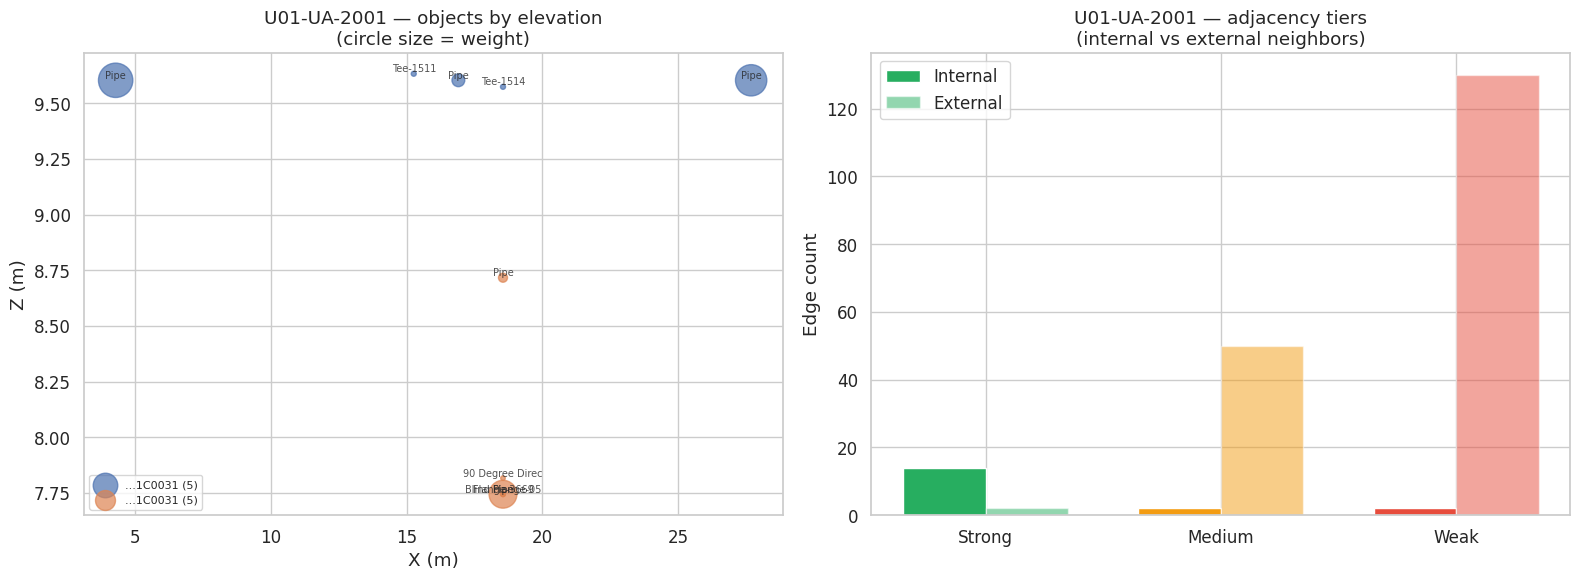

=== U01-UA-2001 Installation Sequence (bottom-up) ===
Step  Name                       PipeRun                 z(m)        kg      Tier
   1  Blind Flange-0513          ...1C0031                7.7      12.7          
   2  Flange-3669                ...1C0031                7.7      10.9      Weak
   3  Pipe                       ...1C0031                7.7     401.8    Strong
   4  90 Degree Direction Chang  ...1C0031                7.8      10.9    Strong
   5  Pipe                       ...1C0031                8.7      42.0    Strong
   6  Tee-1514                   ...1C0031                9.6      13.2    Strong
   7  Pipe                       ...1C0031                9.6     508.2    Strong
   8  Pipe                       ...1C0031                9.6      84.8          
   9  Pipe                       ...1C0031                9.6     612.1          
  10  Tee-1511                   ...1C0031                9.6      13.2    Medium


In [5]:
PIPELINE = "U01-UA-2001"
pipe_objs = gold[gold["sp3d_pipeline"] == PIPELINE].copy()
pipe_ids = set(pipe_objs["object_id"])

# Internal adjacency
adj_internal = adj[adj["source_object_id"].isin(pipe_ids) & adj["target_object_id"].isin(pipe_ids)]
# External adjacency (pipeline member ↔ outside)
adj_external = adj[
    (adj["source_object_id"].isin(pipe_ids) & ~adj["target_object_id"].isin(pipe_ids)) |
    (~adj["source_object_id"].isin(pipe_ids) & adj["target_object_id"].isin(pipe_ids))
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: pipeline objects by elevation, colored by PipeRun
for pr, group in pipe_objs.groupby("sp3d_pipe_run"):
    short = str(pr).split("-")[-1][:15]
    axes[0].scatter(group["centroid_x"], group["centroid_z"], s=group["dry_weight_kg"].fillna(10),
                    alpha=0.7, label=f"...{short} ({len(group)})")
    for _, row in group.iterrows():
        name = str(row["display_name"])[:15] if pd.notna(row["display_name"]) else "?"
        axes[0].annotate(name, (row["centroid_x"], row["centroid_z"]),
                        fontsize=7, alpha=0.8, ha="center", va="bottom")
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Z (m)")
axes[0].set_title(f"{PIPELINE} — objects by elevation\n(circle size = weight)")
axes[0].legend(fontsize=8)

# Right: internal adjacency by tier
tier_counts_int = adj_internal["tier"].value_counts()
tier_counts_ext = adj_external["tier"].value_counts().reindex(["Strong", "Medium", "Weak"]).fillna(0)
x = np.arange(3)
width = 0.35
axes[1].bar(x - width/2, tier_counts_int.reindex(["Strong", "Medium", "Weak"]).fillna(0),
            width, label="Internal", color=["#27ae60", "#f39c12", "#e74c3c"])
axes[1].bar(x + width/2, tier_counts_ext,
            width, label="External", color=["#27ae60", "#f39c12", "#e74c3c"], alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Strong", "Medium", "Weak"])
axes[1].set_ylabel("Edge count")
axes[1].set_title(f"{PIPELINE} — adjacency tiers\n(internal vs external neighbors)")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / "03_s4_pipeline_case_study.png", dpi=300, bbox_inches="tight")
plt.show()

# Installation sequence
print(f"=== {PIPELINE} Installation Sequence (bottom-up) ===")
print(f"{'Step':>4}  {'Name':25s}  {'PipeRun':20s}  {'z(m)':>6}  {'kg':>8}  {'Tier':>8}")
for i, (_, row) in enumerate(pipe_objs.sort_values("centroid_z").iterrows()):
    pr_short = str(row["sp3d_pipe_run"]).split("-")[-1][:15] if pd.notna(row["sp3d_pipe_run"]) else "?"
    name = str(row["display_name"])[:25] if pd.notna(row["display_name"]) else "?"
    wt = f"{row['dry_weight_kg']:.1f}" if pd.notna(row["dry_weight_kg"]) else "-"
    # Find adjacency tier to previous object
    tier = ""
    if i > 0:
        prev_id = pipe_objs.sort_values("centroid_z").iloc[i-1]["object_id"]
        edge = adj_internal[
            ((adj_internal["source_object_id"] == prev_id) & (adj_internal["target_object_id"] == row["object_id"])) |
            ((adj_internal["source_object_id"] == row["object_id"]) & (adj_internal["target_object_id"] == prev_id))
        ]
        if not edge.empty:
            tier = edge.iloc[0]["tier"]
    print(f"{i+1:>4}  {name:25s}  ...{pr_short:17s}  {row['centroid_z']:6.1f}  {wt:>8}  {tier:>8}")

## 5. Neo4j 환경 및 Cypher 질의 참조

### 환경 설정
```bash
# Neo4j Docker 실행
docker run -d --name bimkg-neo4j -p 7474:7474 -p 7687:7687 \
  -e NEO4J_AUTH=neo4j/bimkg2026 \
  -v "$(realpath data/ontology/2026-04-12/neo4j)":/import \
  neo4j:5-community

# 접속: http://localhost:7474 (neo4j / bimkg2026)
# 중지: docker stop bimkg-neo4j
# 재시작: docker start bimkg-neo4j
```

### Cypher 질의 — 파이프라인 시공 순서 확인
```cypher
-- 파이프라인 내부 연결 + 시공 순서
MATCH (obj:BIMObject)-[:BELONGS_TO_PIPELINE]->(p:Pipeline {name: "U01-UA-2001"})
OPTIONAL MATCH (obj)-[adj:ADJACENT_TO]-(other:BIMObject)-[:BELONGS_TO_PIPELINE]->(p)
OPTIONAL MATCH (obj)-[prec:MUST_PRECEDE]->(next:BIMObject)-[:BELONGS_TO_PIPELINE]->(p)
RETURN obj, p, adj, other, prec, next

-- 파이프라인 + 주변 구조물 (touch 만)
MATCH (obj:BIMObject)-[:BELONGS_TO_PIPELINE]->(p:Pipeline {name: "U01-UA-2001"})
MATCH (obj)-[r:ADJACENT_TO]-(ext:BIMObject)
WHERE r.relationType IN ["touch", "neartouch"]
RETURN obj, p, r, ext

-- 존 경계의 연결 유형별 분포
MATCH (a:BIMObject)-[:IN_ZONE]->(z1:Zone),
      (b:BIMObject)-[:IN_ZONE]->(z2:Zone),
      (a)-[r:ADJACENT_TO]-(b)
WHERE z1.zoneNumber < z2.zoneNumber
WITH z1.zoneNumber AS zone1, z2.zoneNumber AS zone2,
     r.relationType AS relType, count(*) AS cnt
RETURN zone1, zone2, relType, cnt
ORDER BY cnt DESC LIMIT 20

-- 존 간 시공 의존성
MATCH (a:BIMObject)-[:IN_ZONE]->(z1:Zone),
      (a)-[:MUST_PRECEDE]->(b:BIMObject),
      (b)-[:IN_ZONE]->(z2:Zone)
WHERE z1 <> z2
WITH z1.zoneNumber AS fromZone, z2.zoneNumber AS toZone, count(*) AS deps
RETURN fromZone, toZone, deps ORDER BY deps DESC LIMIT 15
```